# IMPORT IMPORTANT LIBRARY AND LOADING DATASET

In [1]:

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub


/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv")

# STATISTICAL ANALYSIS

In [3]:
df.shape

(10000, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Buyer_ID                     10000 non-null  object 
 1   Age                          10000 non-null  int64  
 2   Gender                       10000 non-null  object 
 3   Annual_Income_USD            9822 non-null   float64
 4   City_Type                    10000 non-null  object 
 5   Daily_Commute_km             9819 non-null   float64
 6   Number_of_Cars_Owned         10000 non-null  int64  
 7   Current_Car_Type             10000 non-null  object 
 8   Charging_Stations_Near_Home  10000 non-null  int64  
 9   Charging_Stations_Near_Work  10000 non-null  int64  
 10  Home_Charging_Possible       10000 non-null  object 
 11  Environmental_Concern_Level  9816 non-null   float64
 12  Subsidy_Available            10000 non-null  object 
 13  Range_Anxiety_Lev

In [5]:
df.describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,10000.000000,9822.000000,9819.000000,10000.000000,10000.000000,10000.000000,9816.000000
mean,46.936200,85378.485848,41.105418,1.859900,5.346900,7.458200,2.982783
std,12.945968,32838.684167,23.351276,0.855421,4.049074,5.259374,1.413784
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,36.000000,61369.500000,23.250000,1.000000,2.000000,3.000000,2.000000
50%,47.000000,84708.000000,40.200000,2.000000,5.000000,6.000000,3.000000
75%,58.000000,107383.250000,57.000000,2.000000,8.000000,11.000000,4.000000
max,69.000000,223345.000000,135.500000,4.000000,14.000000,19.000000,5.000000


In [6]:
df.nunique()

Buyer_ID                       10000
Age                               45
Gender                             3
Annual_Income_USD               8915
City_Type                          3
Daily_Commute_km                 991
Number_of_Cars_Owned               4
Current_Car_Type                   4
Charging_Stations_Near_Home       15
Charging_Stations_Near_Work       20
Home_Charging_Possible             2
Environmental_Concern_Level        5
Subsidy_Available                  2
Range_Anxiety_Level                3
Will_Buy_EV                        2
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## drop unnecessary column

In [8]:
df=df.drop(columns=['Buyer_ID'])

# HANDLING NULL VALUES 

In [9]:
count=df.isnull().sum()
print(count)

Age                              0
Gender                           0
Annual_Income_USD              178
City_Type                        0
Daily_Commute_km               181
Number_of_Cars_Owned             0
Current_Car_Type                 0
Charging_Stations_Near_Home      0
Charging_Stations_Near_Work      0
Home_Charging_Possible           0
Environmental_Concern_Level    184
Subsidy_Available                0
Range_Anxiety_Level              0
Will_Buy_EV                      0
dtype: int64


In [10]:
cat_col=['Annual_Income_USD','Daily_Commute_km','Environmental_Concern_Level']
for c in cat_col:
    df[c]=df[c].fillna(df[c].median())
    

# OUTLIER HANDLING

In [11]:
num_col=df.select_dtypes(include=[np.number]).columns
outlier=pd.DataFrame(False,index=df.index,columns=num_col)

for c in num_col:
    x=df[c]
    mean=x.mean(skipna=True)
    std=x.std(skipna=True)
    if std==0 or np.isnan(std):
        continue

    z=(x-mean)/std
    outlier[c]=z.abs()>3

count=outlier.sum().sort_values(ascending=False)
print(count)

Annual_Income_USD              37
Daily_Commute_km               31
Age                             0
Number_of_Cars_Owned            0
Charging_Stations_Near_Home     0
Charging_Stations_Near_Work     0
Environmental_Concern_Level     0
dtype: int64


In [12]:
outlier_col=['Annual_Income_USD','Daily_Commute_km']
for c in outlier_col:
    low=df[c].quantile(0.01)
    high=df[c].quantile(0.99)
    df[c]=df[c].clip(lower=low,upper=high)

## convert terget column to numerical format

In [13]:
df['Will_Buy_EV']=(
    df['Will_Buy_EV'].astype(str).str.strip().str.lower().map({"yes":1,"no":0}).astype(int)
)

# CORRELATION

In [14]:
corr=df.corr(numeric_only=True)
trget_corr=corr["Will_Buy_EV"].drop("Will_Buy_EV")
trget_corr

Age                            0.004303
Annual_Income_USD              0.172046
Daily_Commute_km              -0.026966
Number_of_Cars_Owned           0.000362
Charging_Stations_Near_Home   -0.002800
Charging_Stations_Near_Work    0.001259
Environmental_Concern_Level    0.362754
Name: Will_Buy_EV, dtype: float64

# EDA

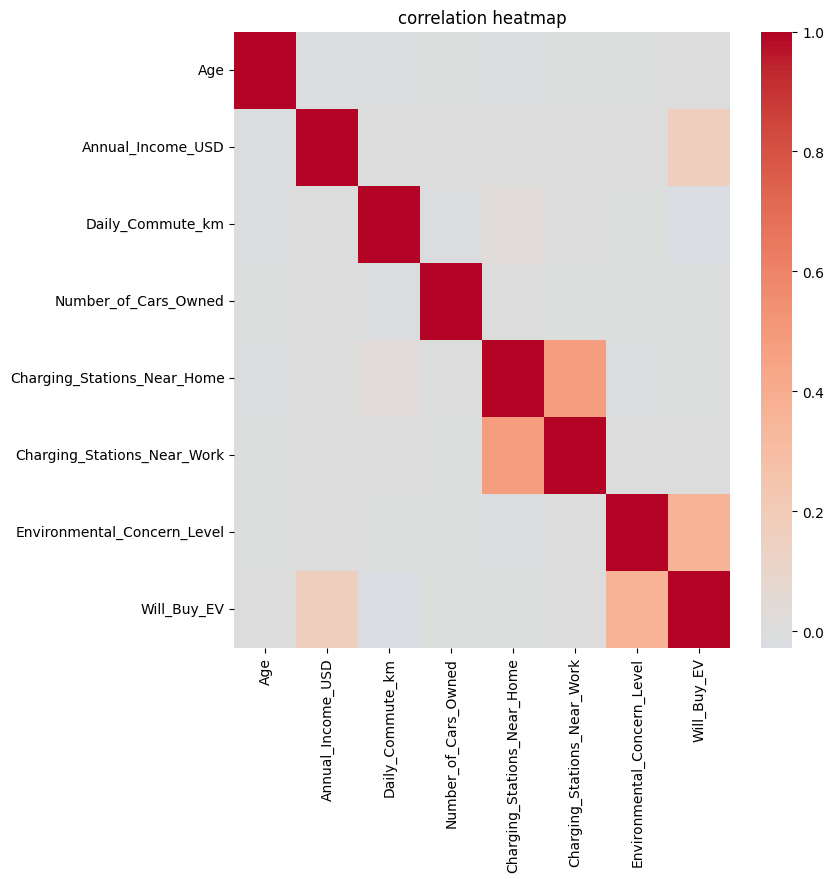

In [15]:
# correlation with terget 
corr=df.corr(numeric_only=True)
plt.figure(figsize=(8,8))
sns.heatmap(corr,cmap="coolwarm",center=0,square=False)
plt.title("correlation heatmap")
plt.show()

## DISTRIBUTION OF IMPORTANT COLUMNS

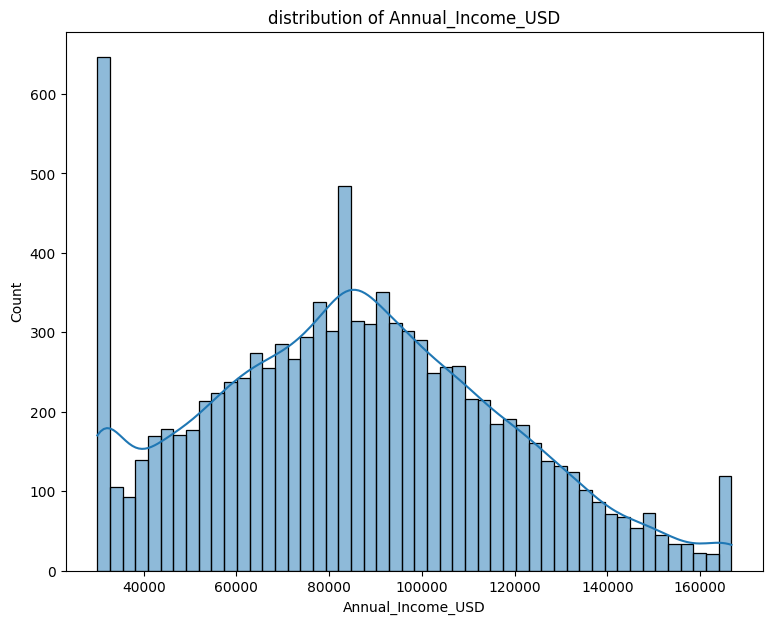

In [16]:
col='Annual_Income_USD'
plt.figure(figsize=(9,7))
sns.histplot(df[col].dropna(),bins=50,kde=True)
plt.title("distribution of Annual_Income_USD")
plt.show()

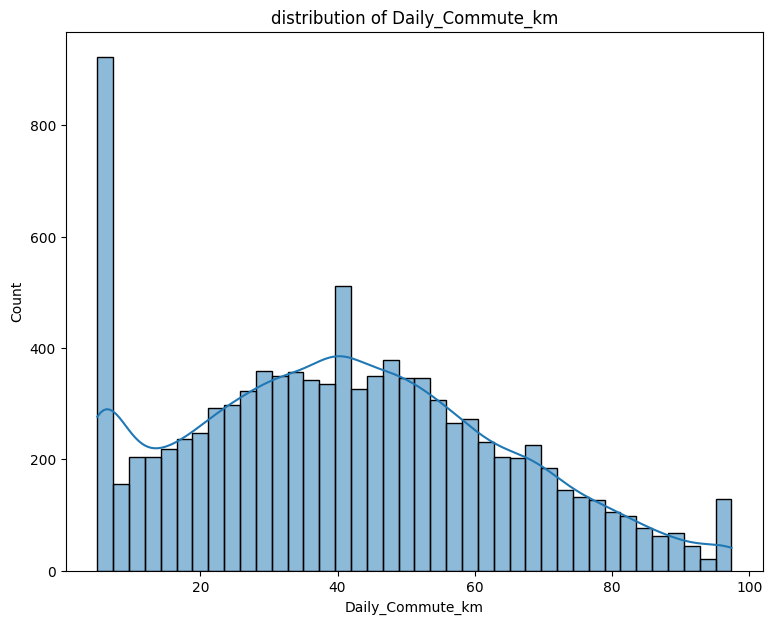

In [17]:
col='Daily_Commute_km'
plt.figure(figsize=(9,7))
sns.histplot(df[col].dropna(),bins=40,kde=True)
plt.title("distribution of Daily_Commute_km")
plt.show()

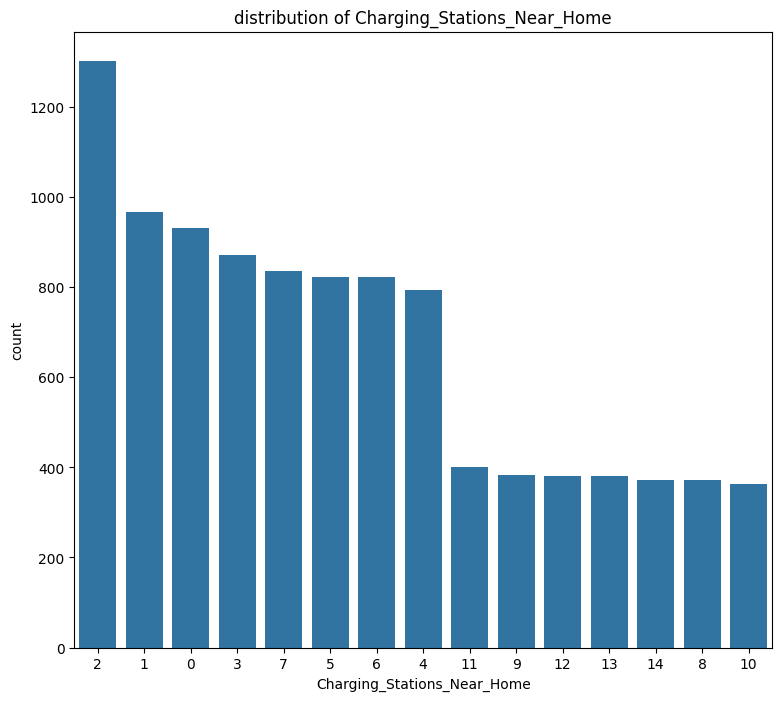

In [18]:
col='Charging_Stations_Near_Home'
plt.figure(figsize=(9,8))
sns.countplot(data=df,x=col,order=df[col].value_counts().index)
plt.title("distribution of Charging_Stations_Near_Home")
plt.show()

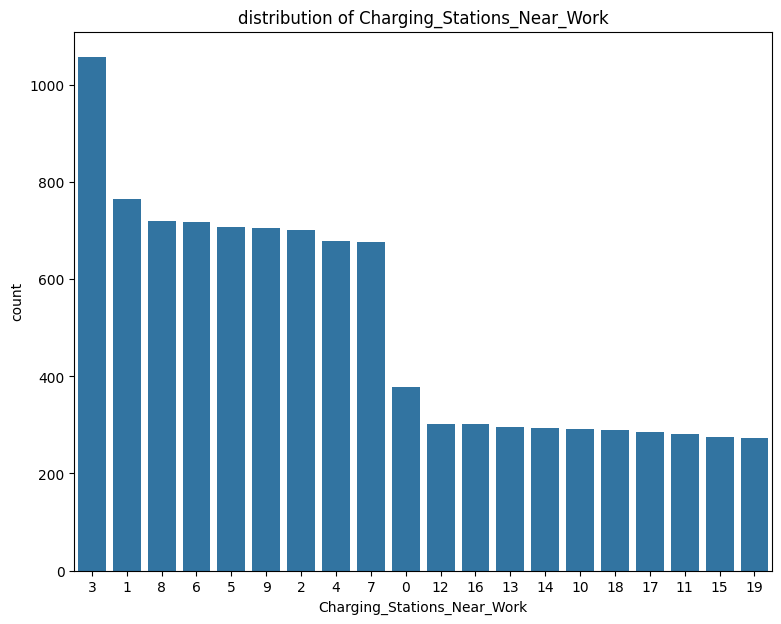

In [19]:
col='Charging_Stations_Near_Work'
plt.figure(figsize=(9,7))
sns.countplot(data=df,x=col,order=df[col].value_counts().index)
plt.title("distribution of Charging_Stations_Near_Work")
plt.show()

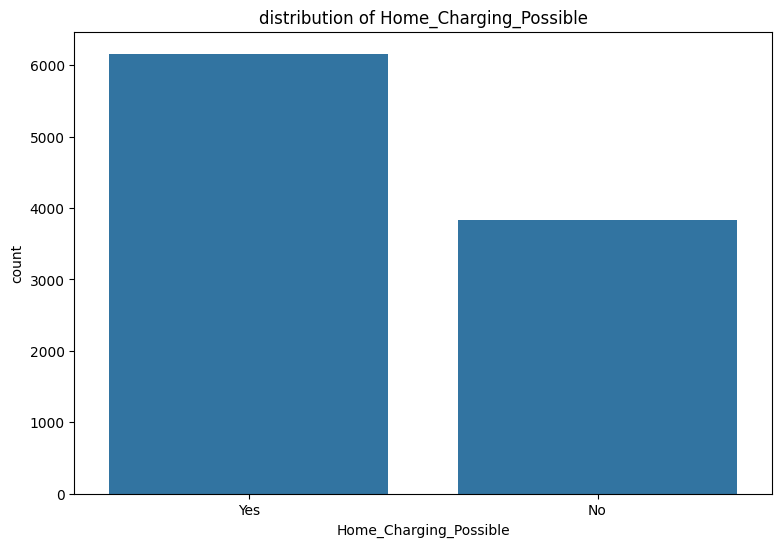

In [20]:
col='Home_Charging_Possible'
plt.figure(figsize=(9,6))
sns.countplot(data=df,x=col)
plt.title("distribution of Home_Charging_Possible")
plt.show()

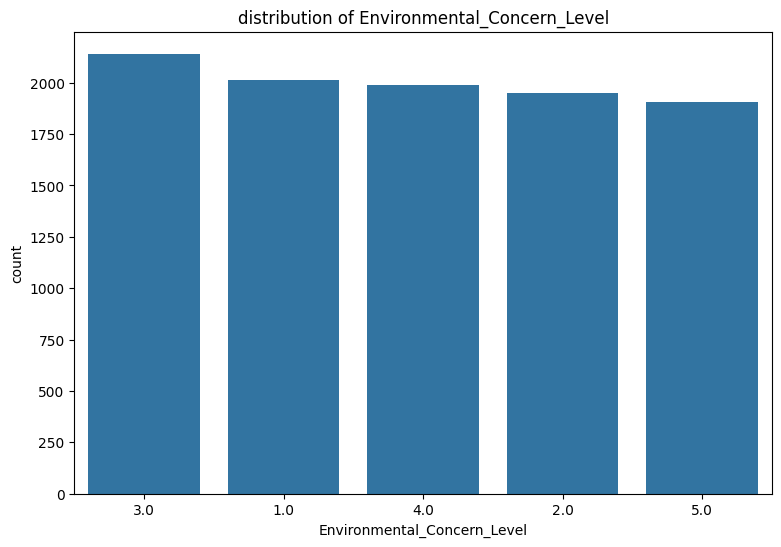

In [21]:
col='Environmental_Concern_Level'
plt.figure(figsize=(9,6))
sns.countplot(data=df,x=col,order=df[col].value_counts().index)
plt.title("distribution of Environmental_Concern_Level")
plt.show()

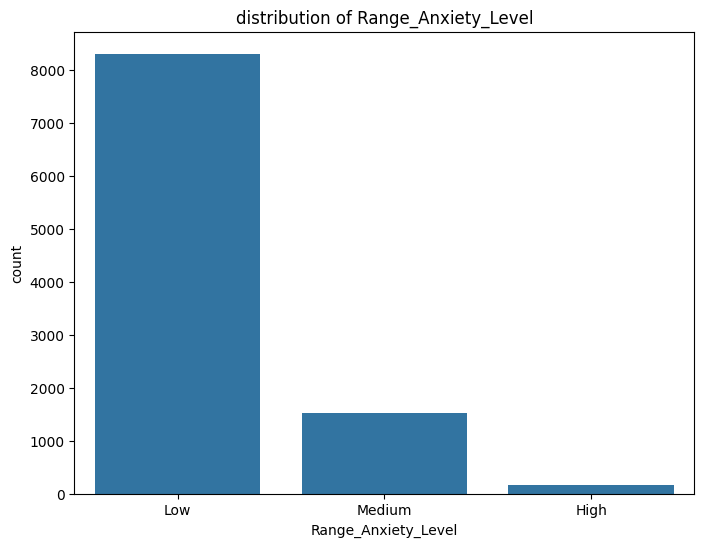

In [22]:
col='Range_Anxiety_Level'
plt.figure(figsize=(8,6))
sns.countplot(data=df,x=col,order=df[col].value_counts().index)
plt.title("distribution of Range_Anxiety_Level")
plt.show()

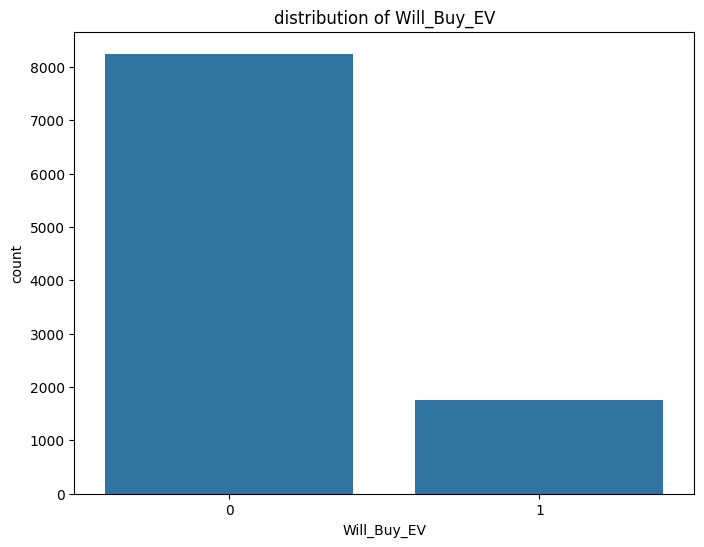

In [23]:
col='Will_Buy_EV'
plt.figure(figsize=(8,6))
sns.countplot(data=df,x=col,order=df[col].value_counts().index)
plt.title("distribution of Will_Buy_EV")
plt.show()

# SPLITING THE DATASET

In [24]:
X=df.drop(columns=["Will_Buy_EV"])
y=df['Will_Buy_EV']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# ENCODING CATEGORICAL COLUMNS

In [25]:
cat_col=X_train.select_dtypes(include=["object"]).columns

preprocess=ColumnTransformer(
    transformers=[
        ("cat",Pipeline(steps=[
            ("imputer",SimpleImputer(strategy="most_frequent")),
            ("onehot",OneHotEncoder(handle_unknown="ignore"))
        ]),cat_col)
        
    ],
    remainder="passthrough"
)

X_train_enc=preprocess.fit_transform(X_train)
X_test_enc=preprocess.transform(X_test)

# TRAINING PHASE

## logistic regression

In [26]:
lr=LogisticRegression(max_iter=1000,class_weight="balanced")
lr.fit(X_train_enc,y_train)
pred=lr.predict(X_test_enc)

print(confusion_matrix(y_test,pred))
print("*****************")
print(classification_report(y_test,pred))

[[1257  392]
 [  54  297]]
*****************
              precision    recall  f1-score   support

           0       0.96      0.76      0.85      1649
           1       0.43      0.85      0.57       351

    accuracy                           0.78      2000
   macro avg       0.69      0.80      0.71      2000
weighted avg       0.87      0.78      0.80      2000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## random forest

In [27]:
rf=RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf.fit(X_train_enc,y_train)
pred=rf.predict(X_test_enc)

print(confusion_matrix(y_test,pred))
print("*****************")
print(classification_report(y_test,pred))

[[1582   67]
 [ 194  157]]
*****************
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1649
           1       0.70      0.45      0.55       351

    accuracy                           0.87      2000
   macro avg       0.80      0.70      0.73      2000
weighted avg       0.86      0.87      0.86      2000



## svm

In [28]:
svm=SVC(kernel="rbf",class_weight="balanced",probability=True,random_state=42)
svm.fit(X_train_enc,y_train)
pred=svm.predict(X_test_enc)
print(confusion_matrix(y_test,pred))
print("***********************")
print(classification_report(y_test,pred))

[[817 832]
 [109 242]]
***********************
              precision    recall  f1-score   support

           0       0.88      0.50      0.63      1649
           1       0.23      0.69      0.34       351

    accuracy                           0.53      2000
   macro avg       0.55      0.59      0.49      2000
weighted avg       0.77      0.53      0.58      2000



## XGBoost

In [29]:
from xgboost import XGBClassifier
xgb=XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
)
xgb.fit(X_train_enc,y_train)
pred=xgb.predict(X_test_enc)
print(confusion_matrix(y_test,pred))
print("*******************")
print(classification_report(y_test,pred))

[[1370  279]
 [  75  276]]
*******************
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      1649
           1       0.50      0.79      0.61       351

    accuracy                           0.82      2000
   macro avg       0.72      0.81      0.75      2000
weighted avg       0.87      0.82      0.84      2000



## lgbm

In [30]:
from lightgbm import LGBMClassifier
lgbm=LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
)
lgbm.fit(X_train_enc,y_train)
pred=lgbm.predict(X_test_enc)
print(confusion_matrix(y_test,pred))
print("**************")
print(classification_report(y_test,pred))

[LightGBM] [Info] Number of positive: 1399, number of negative: 6601
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001999 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 636
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174875 -> initscore=-1.551463
[LightGBM] [Info] Start training from score -1.551463
[[1436  213]
 [ 107  244]]
**************
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      1649
           1       0.53      0.70      0.60       351

    accuracy                           0.84      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.86      0.84      0.85      2000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## catboost

In [31]:
from catboost import CatBoostClassifier
cat=CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_state=42,
    verbose=False,
    auto_class_weights="Balanced"
)

cat.fit(X_train_enc,y_train)
pred=cat.predict(X_test_enc)

print(confusion_matrix(y_test,pred))
print("*******************")
print(classification_report(y_test,pred))

[[1429  220]
 [ 107  244]]
*******************
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      1649
           1       0.53      0.70      0.60       351

    accuracy                           0.84      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.86      0.84      0.84      2000

